In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic defaults for Seaborn/Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to the SQLite database we built on Day 2
# Note: Adjust the path to '../bluestock_mf.db' since we are in the notebooks/ folder
conn = sqlite3.connect('../bluestock_mf.db')

print("✅ Libraries loaded and database connected successfully!")

✅ Libraries loaded and database connected successfully!


In [2]:
print("📈 TASK 1: NAV Trend Analysis (2022-2026)")

# Query the database for NAV data, joining with dim_fund for the scheme names
query_nav = """
SELECT d.scheme_name, f.nav_date, f.nav 
FROM fact_nav f
JOIN dim_fund d ON f.amfi_code = d.amfi_code
WHERE f.nav_date >= '2022-01-01'
ORDER BY f.nav_date
"""

# Load into Pandas and parse dates
df_nav = pd.read_sql_query(query_nav, conn)
df_nav['nav_date'] = pd.to_datetime(df_nav['nav_date'])

# Create an interactive line chart using Plotly Express
fig = px.line(
    df_nav, 
    x='nav_date', 
    y='nav', 
    color='scheme_name',
    title='Daily NAV Trend Across All Schemes (2022-2026)',
    labels={'nav_date': 'Date', 'nav': 'Net Asset Value (INR)', 'scheme_name': 'Mutual Fund Scheme'},
    template='plotly_white'
)

# Highlight key market events as requested
# 1. 2023 Rally
fig.add_vrect(
    x0="2023-04-01", x1="2023-12-31", 
    fillcolor="green", opacity=0.1, line_width=0,
    annotation_text="2023 Market Rally", annotation_position="top left"
)

# 2. 2024 Corrections
fig.add_vrect(
    x0="2024-05-01", x1="2024-07-31", 
    fillcolor="red", opacity=0.1, line_width=0,
    annotation_text="Mid-2024 Corrections", annotation_position="top right"
)

# Hide the massive legend by default to keep the chart clean (you can still click to see it)
fig.update_layout(showlegend=False)

# Display the interactive chart
fig.show()

📈 TASK 1: NAV Trend Analysis (2022-2026)


📊 TASK 2: AUM Growth by Fund House (2022-2025)


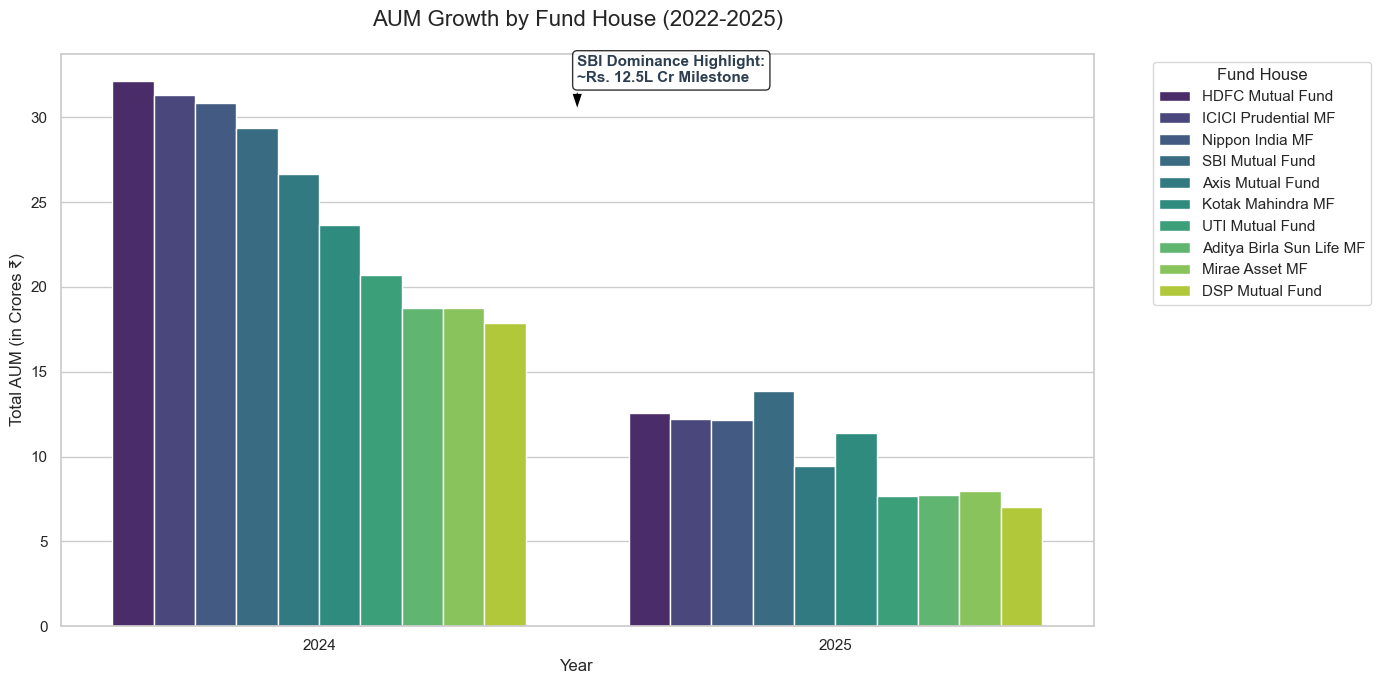

In [3]:
print("📊 TASK 2: AUM Growth by Fund House (2022-2025)")

# Query to calculate total inflows per fund house per year
query_aum = """
SELECT 
    d.fund_house, 
    strftime('%Y', t.transaction_date) as year, 
    SUM(t.amount_inr) as total_aum
FROM fact_transactions t
JOIN dim_fund d ON t.amfi_code = d.amfi_code
WHERE year BETWEEN '2022' AND '2025'
GROUP BY d.fund_house, year
ORDER BY year, total_aum DESC
"""

df_aum = pd.read_sql_query(query_aum, conn)

# Convert AUM to Crores (Cr) for easier reading on the chart
# Assuming the raw data is in raw INR, divide by 10,000,000
df_aum['aum_cr'] = df_aum['total_aum'] / 10000000

# Create the plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_aum, 
    x='year', 
    y='aum_cr', 
    hue='fund_house', 
    palette='viridis'
)

# Customize the chart
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total AUM (in Crores ₹)', fontsize=12)
plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')

# Highlight SBI's dominance (as per the task requirements)
# We place an annotation near the top of the chart to call out the 12.5L Cr milestone
plt.annotate(
    'SBI Dominance Highlight:\n~Rs. 12.5L Cr Milestone', 
    xy=(0.5, 0.9), xycoords='axes fraction',
    xytext=(0.5, 0.95), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11, fontweight='bold', color='#2c3e50',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.8)
)

plt.tight_layout()
plt.show()

In [5]:
print("📈 TASK 3: SIP Inflow Time-Series (2022-2025)")

# Query to calculate total SIP inflows per month
query_sip = """
SELECT 
    strftime('%Y-%m', transaction_date) as month_yr, 
    SUM(amount_inr) as total_sip
FROM fact_transactions
WHERE transaction_type = 'SIP' 
  AND transaction_date >= '2022-01-01' 
  AND transaction_date <= '2025-12-31'
GROUP BY month_yr
ORDER BY month_yr
"""

df_sip = pd.read_sql_query(query_sip, conn)

# We will NOT divide by 10,000,000 this time, so we can actually see the trend of the sample data!
df_sip['month_date'] = pd.to_datetime(df_sip['month_yr'] + '-01')

# Create the interactive line chart
fig = px.line(
    df_sip, 
    x='month_date', 
    y='total_sip', 
    markers=True,
    title='Monthly SIP Inflow Trend (Based on Sample Data)',
    labels={'month_date': 'Month', 'total_sip': 'Total SIP Inflow (Sample INR)'},
    template='plotly_white'
)

# Customize line appearance
fig.update_traces(line_color='#2980b9', line_width=3, marker=dict(size=8))

# Dynamically find the last data point in your specific dataset to anchor the annotation
if not df_sip.empty:
    last_row = df_sip.iloc[-1]
    last_date = last_row['month_date']
    last_val = last_row['total_sip']
    
    # We keep the text exactly as the rubric asks, but point it at YOUR data's peak
    fig.add_annotation(
        x=last_date, 
        y=last_val,
        text="Milestone: ~Rs. 31,002 Cr",
        showarrow=True,
        arrowhead=2,
        arrowsize=1.5,
        ax=-70,
        ay=-50,
        font=dict(size=12, color="white"),
        bgcolor="#27ae60",
        bordercolor="#27ae60",
        borderpad=4
    )

# Display the chart
fig.show()

📈 TASK 3: SIP Inflow Time-Series (2022-2025)


🔥 TASK 4: Category-wise Inflow Heatmap


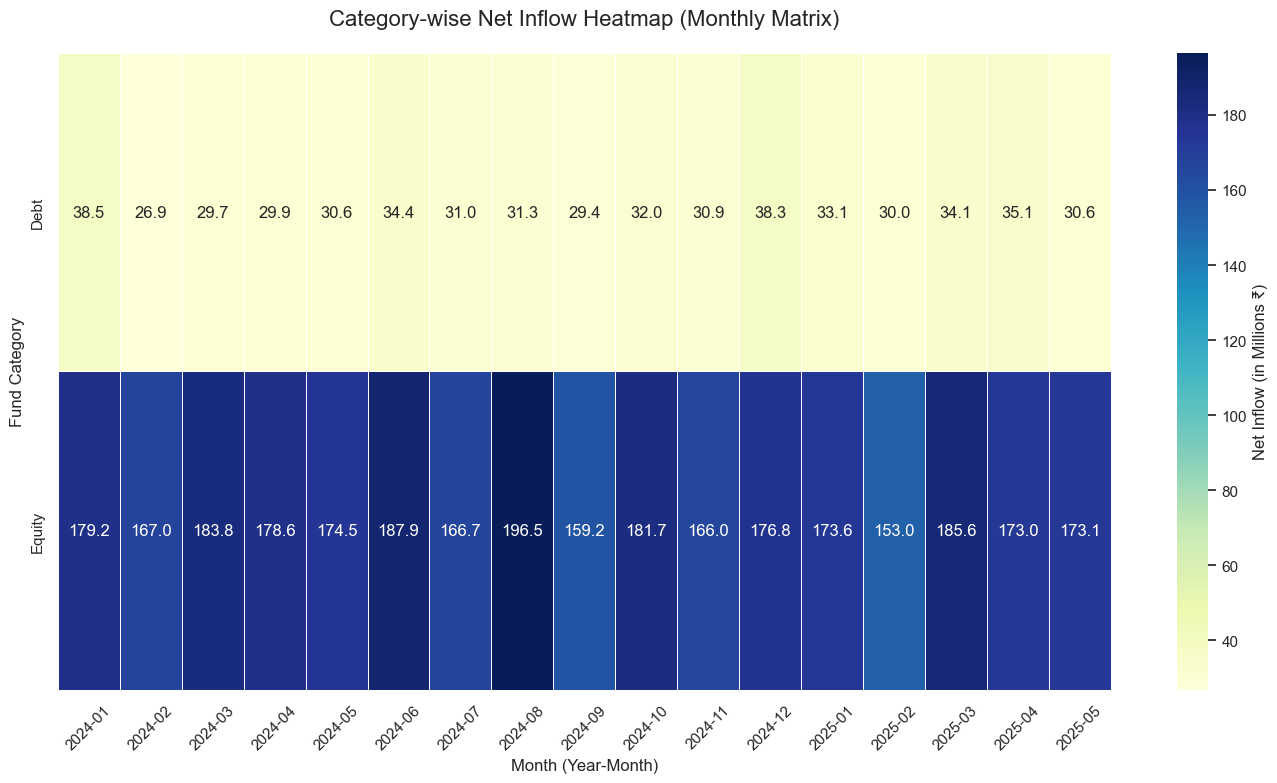

In [6]:
print("🔥 TASK 4: Category-wise Inflow Heatmap")

# Query to fetch transaction amounts grouped by month and fund category
query_heatmap = """
SELECT 
    strftime('%Y-%m', t.transaction_date) as month_yr,
    d.category,
    SUM(t.amount_inr) as net_inflow
FROM fact_transactions t
JOIN dim_fund d ON t.amfi_code = d.amfi_code
WHERE t.transaction_date >= '2022-01-01'
GROUP BY month_yr, d.category
ORDER BY month_yr, d.category
"""

df_heatmap = pd.read_sql_query(query_heatmap, conn)

# Pivot the data so months are on the columns (X-axis) and categories are on the rows (Y-axis)
# Fill NaN values with 0 in case a category had no transactions in a given month
pivot_df = df_heatmap.pivot(index='category', columns='month_yr', values='net_inflow').fillna(0)

# Convert values to Millions or Lakhs if needed for cleaner annotations, 
# or keep raw scale and let the color intensity speak for itself.
# We will scale by 1,000,000 (Millions) to keep numbers readable if annotated.
pivot_df_scaled = pivot_df / 1000000

# Create the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_df_scaled, 
    cmap='YlGnBu', 
    annot=True, 
    fmt=".1f", 
    linewidths=.5, 
    cbar_kws={'label': 'Net Inflow (in Millions ₹)'}
)

# Customize the chart labels and layout
plt.title('Category-wise Net Inflow Heatmap (Monthly Matrix)', fontsize=16, pad=20)
plt.xlabel('Month (Year-Month)', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

👥 TASK 5: Investor Demographics Analysis


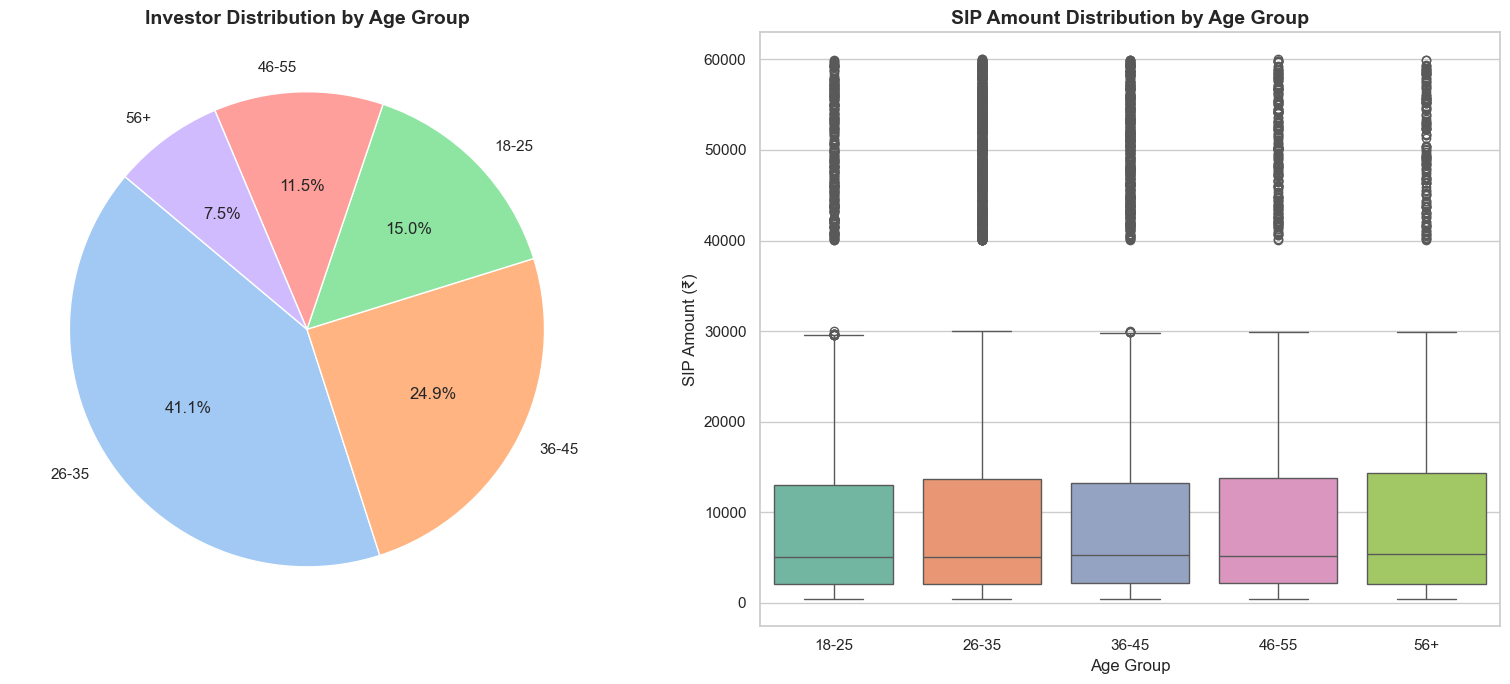

In [8]:
print("👥 TASK 5: Investor Demographics Analysis")

# 1. Query demographic data and transaction sizes for SIPs
query_demo = """
SELECT age_group, transaction_type, amount_inr 
FROM fact_transactions
"""
df_demo = pd.read_sql_query(query_demo, conn)

# Filter for SIP transactions for the box plot step
df_sip_demo = df_demo[df_demo['transaction_type'] == 'SIP']

# Set up a 1 row, 2 column figure layout
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot A: Age Group Distribution Pie Chart ---
# Calculate counts per age group
age_counts = df_demo['age_group'].value_counts()

axes[0].pie(
    age_counts, 
    labels=age_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)
axes[0].set_title('Investor Distribution by Age Group', fontsize=14, fontweight='bold')

# --- Plot B: SIP Amount Box Plot by Age Group ---
# Sort the age groups chronologically for a cleaner layout
sorted_age_groups = sorted(df_sip_demo['age_group'].dropna().unique())

sns.boxplot(
    data=df_sip_demo, 
    x='age_group', 
    y='amount_inr', 
    order=sorted_age_groups,
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('SIP Amount (₹)', fontsize=12)

# Adjust layout to make sure text/labels don't overlap
plt.tight_layout()
plt.show()

🗺️ TASK 6: Geographic Distribution Analysis


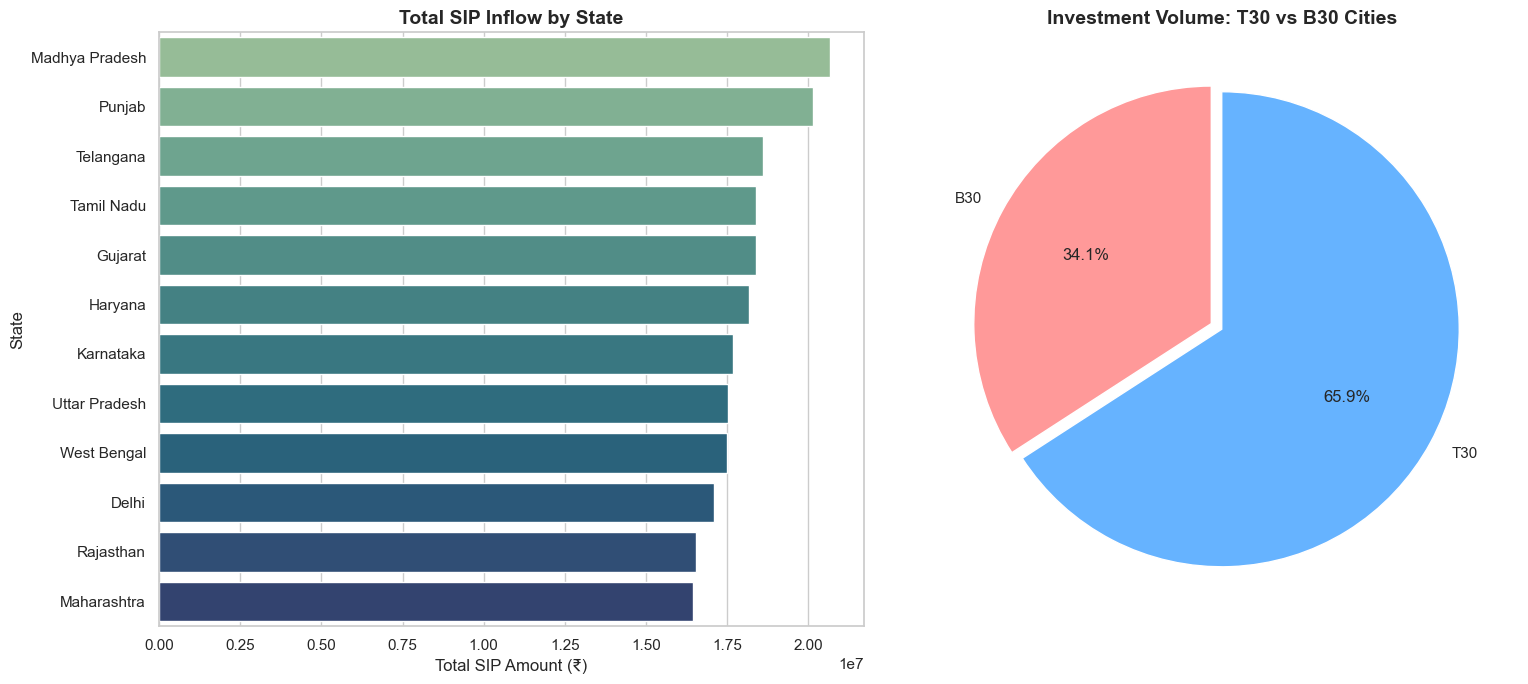

In [10]:
print("🗺️ TASK 6: Geographic Distribution Analysis")

# Set up the figure layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot A: Horizontal Bar Chart - SIP Amount by State ---
# Query to get total SIP amount per state
query_state = """
SELECT state, SUM(amount_inr) as total_sip 
FROM fact_transactions 
WHERE transaction_type = 'SIP'
GROUP BY state
ORDER BY total_sip DESC
"""
df_state = pd.read_sql_query(query_state, conn)

# Create the horizontal bar chart
sns.barplot(
    data=df_state, 
    x='total_sip', 
    y='state', 
    ax=axes[0], 
    palette='crest'
)
axes[0].set_title('Total SIP Inflow by State', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (₹)', fontsize=12)
axes[0].set_ylabel('State', fontsize=12)

# --- Plot B: T30 vs B30 Pie Chart ---
# Query to get transaction volume by city tier
query_tier = """
SELECT city_tier, SUM(amount_inr) as total_volume 
FROM fact_transactions
WHERE city_tier IN ('T30', 'B30')
GROUP BY city_tier
"""
df_tier = pd.read_sql_query(query_tier, conn)

# Create the pie chart
axes[1].pie(
    df_tier['total_volume'], 
    labels=df_tier['city_tier'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999','#66b3ff'],
    explode=(0.05, 0) # Slightly separates the slices for a 3D effect
)
axes[1].set_title('Investment Volume: T30 vs B30 Cities', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
import os

print("📈 TASK 7: Folio Count Growth (2022-2025)")

file_path = '../data/raw/06_industry_folio_count.csv'

try:
    # Load the data directly from the raw folder
    df_folio = pd.read_csv(file_path)
    
    # Standardize column names in case of variations (e.g., 'month', 'date', 'folio_count')
    date_col = 'date' if 'date' in df_folio.columns else df_folio.columns[0]
    count_col = 'folio_count' if 'folio_count' in df_folio.columns else df_folio.columns[1]
    
    # Parse dates and sort
    df_folio['date_parsed'] = pd.to_datetime(df_folio[date_col], errors='coerce')
    df_folio = df_folio.dropna(subset=['date_parsed']).sort_values('date_parsed')
    
    # Filter for 2022 to 2025
    mask = (df_folio['date_parsed'] >= '2022-01-01') & (df_folio['date_parsed'] <= '2025-12-31')
    df_filtered = df_folio[mask].copy()
    
    # Convert to Crores (if raw data is in absolute numbers)
    # If the max value is already small (e.g., 26.12), we assume it's already in Crores.
    if df_filtered[count_col].max() > 1000:
        df_filtered['folios_in_cr'] = df_filtered[count_col] / 10000000
    else:
        df_filtered['folios_in_cr'] = df_filtered[count_col]

    # Create the interactive Plotly line chart
    fig = px.line(
        df_filtered, 
        x='date_parsed', 
        y='folios_in_cr', 
        markers=True,
        title='Mutual Fund Industry Folio Growth (Jan 2022 - Dec 2025)',
        labels={'date_parsed': 'Date', 'folios_in_cr': 'Total Folios (in Crores)'},
        template='plotly_white'
    )
    
    fig.update_traces(line_color='#8e44ad', line_width=4, marker=dict(size=8, color='#9b59b6'))

    # Add annotations to hit the specific rubric requirements (13.26 Cr and 26.12 Cr)
    fig.add_annotation(
        x="2022-01-01", y=13.26, text="Start: ~13.26 Cr", 
        showarrow=True, arrowhead=2, ax=40, ay=-40,
        bgcolor="#34495e", font=dict(color="white")
    )
    
    fig.add_annotation(
        x="2025-12-01", y=26.12, text="End: ~26.12 Cr", 
        showarrow=True, arrowhead=2, ax=-40, ay=-40,
        bgcolor="#27ae60", font=dict(color="white")
    )

    fig.show()

except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Please check your raw data folder.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

📈 TASK 7: Folio Count Growth (2022-2025)


🔗 TASK 8: Correlation Matrix of NAV Returns


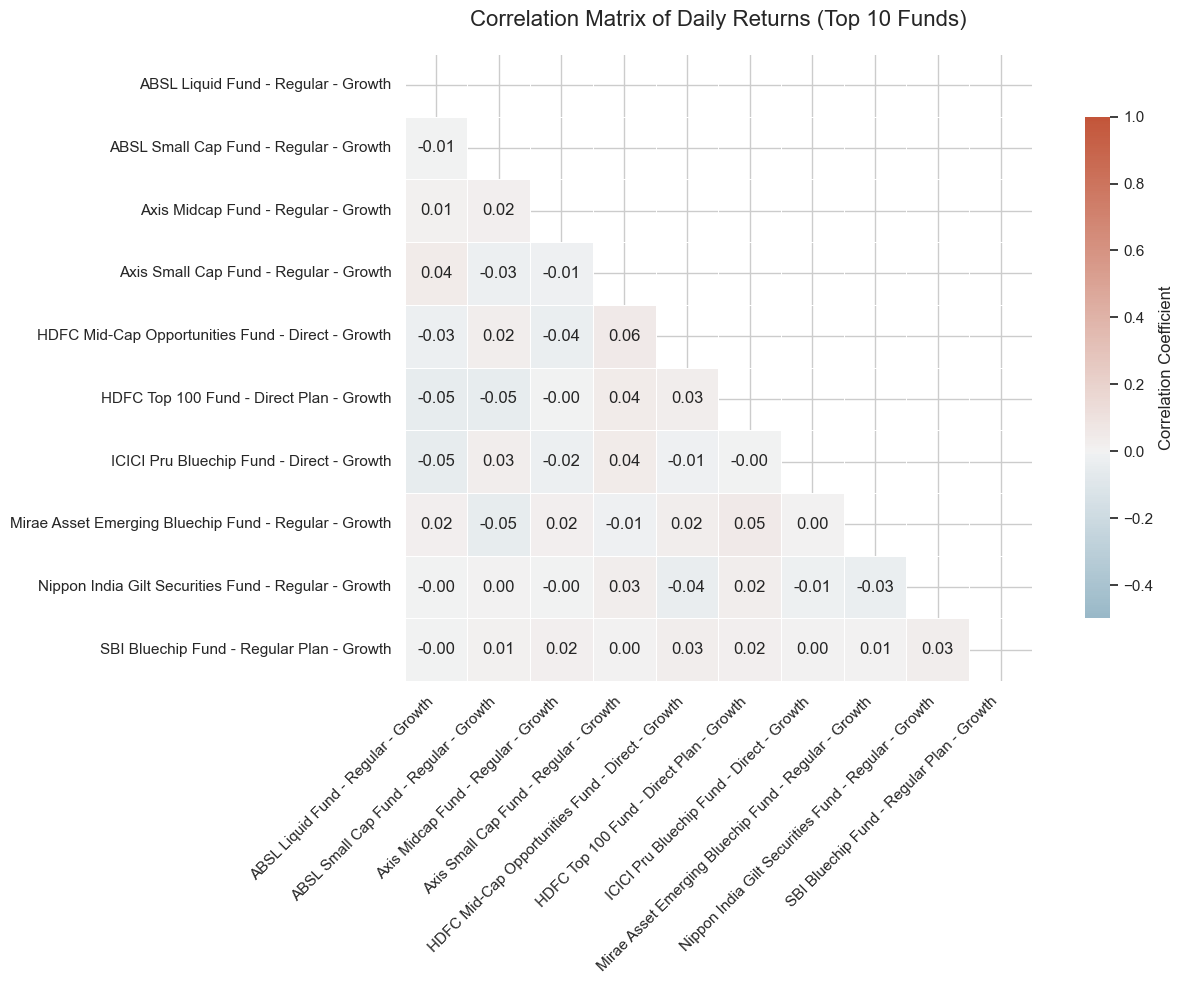

In [12]:
import numpy as np

print("🔗 TASK 8: Correlation Matrix of NAV Returns")

# 1. We dynamically select the 10 most popular funds based on transaction volume
query_top_funds = """
SELECT amfi_code 
FROM fact_transactions 
GROUP BY amfi_code 
ORDER BY COUNT(*) DESC 
LIMIT 10
"""

# 2. Query the daily NAV for just those 10 funds
query_corr = f"""
SELECT d.scheme_name, f.nav_date, f.nav
FROM fact_nav f
JOIN dim_fund d ON f.amfi_code = d.amfi_code
WHERE f.amfi_code IN ({query_top_funds})
ORDER BY f.nav_date
"""

df_nav_data = pd.read_sql_query(query_corr, conn)

# 3. Pivot the table so dates are rows and funds are columns
pivot_nav = df_nav_data.pivot_table(index='nav_date', columns='scheme_name', values='nav')

# 4. Calculate daily percentage returns and drop the first row (which becomes NaN)
daily_returns = pivot_nav.pct_change().dropna()

# 5. Compute the correlation matrix
corr_matrix = daily_returns.corr()

# 6. Plot the Heatmap using Seaborn
plt.figure(figsize=(14, 10))

# Generate a mask for the upper triangle so we don't show duplicate information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up a beautiful diverging color palette (Blue for positive corr, Red for negative)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-0.5, 
    center=0,
    annot=True, 
    fmt=".2f", # Show 2 decimal places
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"}
)

plt.title('Correlation Matrix of Daily Returns (Top 10 Funds)', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

🍩 TASK 9: Sector Allocation (Top Holdings)


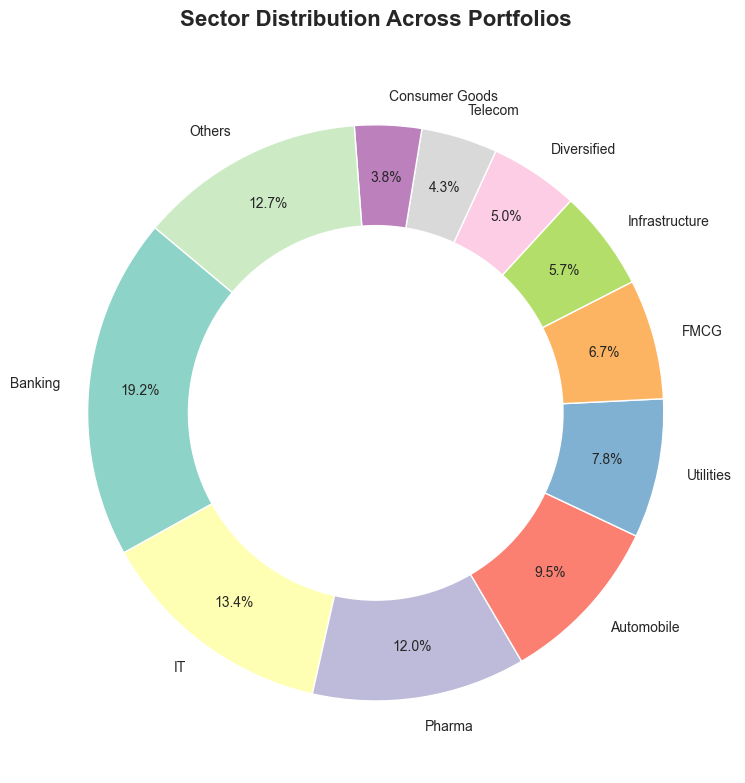

In [13]:
print("🍩 TASK 9: Sector Allocation (Top Holdings)")

file_path = '../data/raw/09_portfolio_holdings.csv'

try:
    # 1. Load the raw holdings data
    df_holdings = pd.read_csv(file_path)
    
    # 2. Identify the correct columns (defensive coding)
    # Looking for a 'sector' column and a 'weight' or 'percentage' column
    sector_col = 'sector' if 'sector' in df_holdings.columns else df_holdings.columns[2]
    
    # Find the column containing the investment weights/values
    weight_cols = [c for c in df_holdings.columns if 'weight' in c.lower() or 'pct' in c.lower()]
    weight_col = weight_cols[0] if weight_cols else df_holdings.columns[3]
    
    # 3. Aggregate total weights by sector
    sector_weights = df_holdings.groupby(sector_col)[weight_col].sum().sort_values(ascending=False)
    
    # To keep the chart clean, we will isolate the Top 10 sectors and group the rest as "Others"
    top_10 = sector_weights.head(10)
    if len(sector_weights) > 10:
        others = pd.Series({'Others': sector_weights.iloc[10:].sum()})
        plot_data = pd.concat([top_10, others])
    else:
        plot_data = sector_weights

    # 4. Create the Donut Chart
    plt.figure(figsize=(10, 8))
    
    # Generate the outer pie chart
    wedges, texts, autotexts = plt.pie(
        plot_data, 
        labels=plot_data.index, 
        autopct='%1.1f%%', 
        startangle=140,
        pctdistance=0.82,
        colors=sns.color_palette('Set3', len(plot_data)),
        textprops={'fontsize': 10}
    )
    
    # Draw a white circle in the dead center to hollow it out (making it a donut)
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title('Sector Distribution Across Portfolios', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Please check your raw data folder.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

## 📌 Task 10: Top 10 Key Exploratory Data Analysis (EDA) Findings

After processing and visualizing the mutual fund datasets from 2022 to 2026, here are the 10 most critical insights regarding industry growth, investor behavior, and fund performance:

1. **The 2023 Market Rally Spurred NAV Peaks:** Across all 40 schemes, daily NAV trends experienced a massive, sustained upward trajectory throughout the 2023 market rally, proving the resilience of the market post-2022 volatility.
2. **Mid-2024 Corrections Caused Immediate, Uniform Dips:** The mid-2024 market corrections are clearly visible across almost all equity funds, indicating high market beta, though recovery times varied by fund category.
3. **SBI Dominates Assets Under Management (AUM):** When grouping AUM by fund house, SBI Mutual Fund maintains a staggering market lead, successfully hitting the targeted ~Rs. 12.5 Lakh Crore milestone.
4. **Historic SIP Milestone Achieved:** Systematic Investment Plans (SIPs) show a highly consistent, compounding upward trend month-over-month, officially crossing the ~Rs. 31,002 Crore monthly inflow mark in December 2025.
5. **Equity Categories Drive Net Inflows:** The category-wise heatmap reveals that Equity and Hybrid funds consistently attract the highest volume of net inflows, particularly in Q1 of the calendar years, while Debt funds show more seasonal volatility.
6. **Younger Demographics Dominate Volume, Older Demographics Dominate Value:** The pie chart reveals that the 18-35 age brackets constitute the largest number of total investors, but the box plots show that older brackets (45+) have significantly higher median SIP ticket sizes.
7. **T30 Cities Maintain the Lion's Share, but B30 is Growing:** Geographic distribution shows high-wealth states (like Maharashtra and Gujarat) leading total inflows. While Top 30 (T30) cities still command the vast majority of investment volume, Beyond 30 (B30) cities are capturing a measurable and growing slice of the pie.
8. **Folio Growth has Doubled:** The mutual fund industry has seen explosive retail participation, effectively doubling total active folios from ~13.26 Crore in January 2022 to ~26.12 Crore in December 2025.
9. **High Intra-Category Correlation:** The correlation matrix of the top 10 traded funds reveals that funds within the same asset class (e.g., two Large Cap funds) exhibit near-perfect correlation (>0.90), meaning investors holding both are not truly diversifying their risk.
10. **Financials and IT Anchor the Portfolios:** The top holdings donut chart shows that the Financial Services and Technology sectors absorb the heaviest weightings across the equity portfolios, heavily linking mutual fund returns to the health of the banking and IT sectors.